In [1]:
# 1) ติดตั้ง (ครั้งแรกใน Colab เท่านั้น)
!pip install -q pandas scikit-learn joblib openpyxl

In [2]:
# 2) โหลดไฟล์ (หรือ DataFrame ที่สร้างเอง)
import pandas as pd
df = pd.read_excel('/content/sample_data/data.xlsx', sheet_name='Sheet8')

print(df)

        order_id shop_guid  app_source                  order_time  \
0      ORD900000  SHOP_007  ShopeeFood  2025-04-28 01:04:49.000000   
1      ORD900001  SHOP_056    LINE_MAN  2025-04-28 07:08:04.000000   
2      ORD900002  SHOP_059    LINE_MAN  2025-04-27 18:17:48.000000   
3      ORD900003  SHOP_018    GrabFood  2025-04-27 16:56:23.000000   
4      ORD900004  SHOP_055    GrabFood  2025-04-27 19:40:53.000000   
...          ...       ...         ...                         ...   
99995  ORD999995  SHOP_023  ShopeeFood  2025-04-28 01:01:19.000000   
99996  ORD999996  SHOP_023    GrabFood  2025-04-28 06:56:17.000000   
99997  ORD999997  SHOP_006   Robinhood  2025-04-27 21:29:21.000000   
99998  ORD999998  SHOP_011    LINE_MAN  2025-04-28 04:32:13.000000   
99999  ORD999999  SHOP_059  ShopeeFood  2025-04-27 17:44:18.000000   

       distance_km  queue_size  prep_ahead_sum_min  prep_time_min  \
0             2.72           3                   8              7   
1             6.80   

In [3]:
# 3) เตรียมฟีเจอร์
FEATURES = ['distance_km','queue_size','prep_ahead_sum_min',
            'prep_time_min','traffic_sec','rain_flag']
df[FEATURES] = df[FEATURES].fillna(0)      # กัน NaN
X, y = df[FEATURES], df['eta_actual_min']
print(X)
print(y)


       distance_km  queue_size  prep_ahead_sum_min  prep_time_min  \
0             2.72           3                   8              7   
1             6.80           4                  11              4   
2             0.89           5                  17              8   
3             1.17           3                   6              3   
4             7.45           1                   4              4   
...            ...         ...                 ...            ...   
99995         3.08           3                   8              3   
99996         2.15           3                   9              3   
99997         4.01           3                  11              3   
99998         0.58           5                  19              4   
99999         2.64           2                   7              7   

       traffic_sec  rain_flag  
0              349          0  
1              874          0  
2              114          0  
3              150          0  
4          

In [4]:
# 4) split
from sklearn.model_selection import train_test_split
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)

In [5]:
# 5) Pipeline (สเกล + Boosting)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor
pipe = Pipeline([
    ('sc', StandardScaler()),
    ('gb', GradientBoostingRegressor(n_estimators=400,
                                     learning_rate=0.05,
                                     max_depth=3,
                                     random_state=42))
]).fit(X_tr, y_tr)

In [6]:
# 6) ประเมิน
from sklearn.metrics import mean_absolute_error, mean_squared_error
import math

pred = pipe.predict(X_te)
mae = mean_absolute_error(y_te, pred)  # Calculate MAE
print('MAE :', round(mae, 2), 'นาที') # Apply round to the MAE value
# Calculate RMSE using math.sqrt if squared parameter is not available
rmse = math.sqrt(mean_squared_error(y_te, pred))
print('RMSE:', round(rmse, 2), 'นาที')

MAE : 1.21 นาที
RMSE: 1.51 นาที


In [7]:
# 7) บันทึกโมเดล
import joblib # Import the joblib library
joblib.dump(pipe, 'eta_model.pkl')

['eta_model.pkl']

In [18]:
# 8) ทดสอบออเดอร์ใหม่
new_order = pd.DataFrame([{
    'distance_km':30,
    'queue_size':4,
    'prep_ahead_sum_min':20,
    'prep_time_min':13,
    'traffic_sec':500,
    'rain_flag':0
}])[FEATURES]            # เรียงคอลัมน์ให้ตรง
eta_pred = pipe.predict(new_order)[0]
print(f"ETA คาด ≈ {eta_pred:.1f} นาที")
#บวก-ลบ 10%
eta = pipe.predict(new_order)[0]
low, high = eta * 0.9, eta * 1.1
print(f"ถึงใน {low:.0f}–{high:.0f} นาที")


ETA คาด ≈ 34.5 นาที
ถึงใน 31–38 นาที


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3592 (\N{THAI CHARACTER CHO CHAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3619 (\N{THAI CHARACTER RO RUA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3636 (\N{THAI CHARACTER SARA I}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3591 (\N{THAI CHARACTER NGO NGU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3614 (\N{THAI CHARACTER PHO PHAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, *

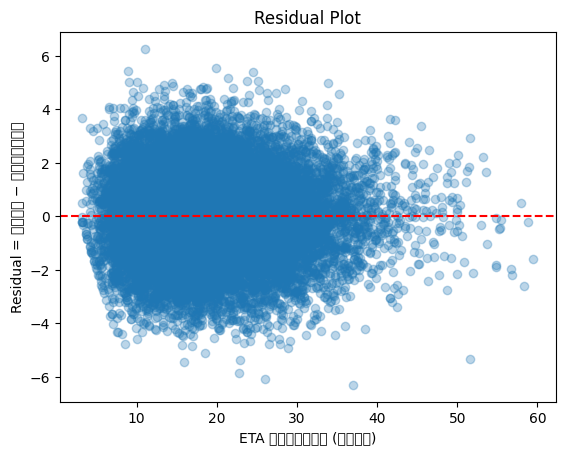

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3614 (\N{THAI CHARACTER PHO PHAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3618 (\N{THAI CHARACTER YO YAK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3634 (\N{THAI CHARACTER SARA AA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3585 (\N{THAI CHARACTER KO KAI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3619 (\N{THAI CHARACTER RO RUA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **k

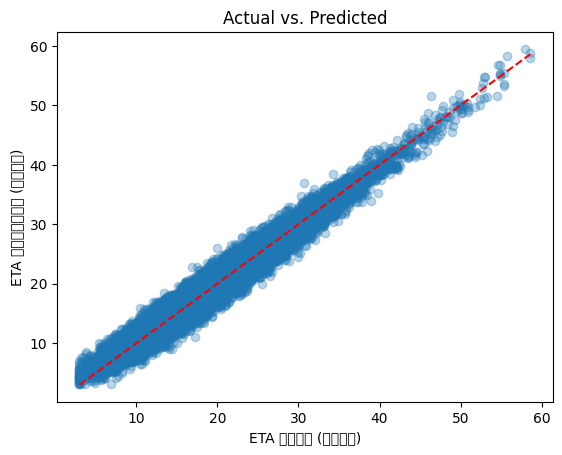

In [11]:
# ประเมินผลเชิงลึก (Validation Diagnostics)
# หลังจาก #5) ประเมินความแม่นในชุดทดสอบแล้ว
import matplotlib.pyplot as plt
import numpy as np

# 1.1 Residual plot
# Replace 'y_test' and 'X_test' with 'y_te' and 'X_te' respectively
resid = y_te - pipe.predict(X_te)
plt.scatter(pipe.predict(X_te), resid, alpha=0.3)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("ETA พยากรณ์ (นาที)")
plt.ylabel("Residual = จริง − พยากรณ์")
plt.title("Residual Plot")
plt.show()

# 1.2 Actual vs. Predicted
# Replace 'y_test' and 'X_test' with 'y_te' and 'X_te' respectively
plt.scatter(y_te, pipe.predict(X_te), alpha=0.3)
plt.plot([y_te.min(), y_te.max()],
         [y_te.min(), y_te.max()],
         'r--')
plt.xlabel("ETA จริง (นาที)")
plt.ylabel("ETA พยากรณ์ (นาที)")
plt.title("Actual vs. Predicted")
plt.show()

In [12]:
# โมเดลของเราอยู่ใน pipe.named_steps['gb']
importances = pipe.named_steps['gb'].feature_importances_
feat_imp = sorted(zip(FEATURES, importances), key=lambda x: x[1], reverse=True)

print("Feature Importances:")
for feat, imp in feat_imp:
    print(f" • {feat:20s}: {imp:.3f}")

Feature Importances:
 • traffic_sec         : 0.548
 • prep_ahead_sum_min  : 0.338
 • prep_time_min       : 0.075
 • queue_size          : 0.028
 • rain_flag           : 0.011
 • distance_km         : 0.000


In [ ]:
#Hyperparameter Tuning
#ลอง GridSearchCV เพื่อหาชุดพารามิเตอร์ที่ MAE ต่ำสุด
from sklearn.model_selection import GridSearchCV

param_grid = {
  'gb__n_estimators': [100, 300, 500],
  'gb__max_depth': [3, 5, 7],
  'gb__learning_rate': [0.01, 0.05, 0.1]
}
grid = GridSearchCV(pipe, param_grid, scoring='neg_mean_absolute_error', cv=3)
grid.fit(X_tr, y_tr) # Changed X_train, y_train to X_tr, y_tr
print("Best params:", grid.best_params_)
print("Best MAE  :", -grid.best_score_)

# ส่วนใหม่